# Netflix Stock Price Prediction with LSTM

In [25]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
import plotly.graph_objects as go

# 1. download clean data (Ensuring no MultiIndex issues)
# 'auto_adjust=True' and 'v2' logic ensures a simpler table
df = yf.download('NFLX', period='6mo', interval='1d', progress=False) # Defines the historical time range you want to retrieve.
                                                                      #1d (1 day), 6mo (6 month), 1y (1 year), max (all available data).

# 2. Force flatten the table (The "Scorched Earth" Fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1) # Kill the 'NFLX' header row

df = df.reset_index() # Move 'Date' from the side to a real column
print(df.tail())

# 3. Use only the last 30 days so candles are thick and visible
df_plot = df.tail(30)

# 4. Create the Candlestick
figure = go.Figure(data=[go.Candlestick(
    x=df_plot['Date'],
    open=df_plot['Open'],
    high=df_plot['High'],
    low=df_plot['Low'],
    close=df_plot['Close']
)])

figure.update_layout(
    title="Netflix Stock Price (Daily Candlesticks)",
    xaxis_rangeslider_visible=False,
    template="plotly_white"
)

figure.show()

/tmp/ipykernel_44287/2706768735.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Price       Date      Close       High        Low       Open    Volume
123   2026-09-10  76.010002  76.300003  75.029999  75.330002  20049000
124   2026-09-11  77.400002  77.570000  76.150002  76.639999  22237800
125   2026-09-14  80.320000  81.019997  78.489998  78.970001  30945100
126   2026-09-15  77.900002  79.480003  77.459999  79.379997  28027400
127   2026-09-16  76.466599  77.800003  76.389999  77.800003  14319057


In [2]:
correlation = df.corr()
print(correlation["Close"].sort_values(ascending=False))

Price
Close     1.000000
Low       0.999387
High      0.999266
Open      0.998263
Date      0.627596
Volume   -0.111747
Name: Close, dtype: float64


In [26]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Define features
x = df[["Open", "High", "Low", "Volume"]]
y = df["Close"]
x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

# train-test split for time-series data
train_size = int(len(x) * 0.7)
val_size = int(len(x) * 0.15)

x_train = x[:train_size]
y_train = y[:train_size]

x_val = x[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

x_test = x[train_size + val_size:]
y_test = y[train_size + val_size:]

# Preprocessing
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# X
x_train_scaled = scaler_x.fit_transform(x_train)
x_val_scaled = scaler_x.transform(x_val)
x_test_scaled = scaler_x.transform(x_test)

# y
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [27]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# LSTM neural network architecture
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(x_train_scaled.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training LSTM

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0518 - mae: 0.1716 - val_loss: 0.0199 - val_mae: 0.1376 - learning_rate: 0.0010
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0111 - mae: 0.0820 - val_loss: 8.5501e-04 - val_mae: 0.0219 - learning_rate: 0.0010
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0083 - mae: 0.0678 - val_loss: 0.0023 - val_mae: 0.0424 - learning_rate: 0.0010
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - mae: 0.0576 - val_loss: 5.4403e-04 - val_mae: 0.0185 - learning_rate: 0.0010
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0521 - val_loss: 0.0020 - val_mae: 0.0402 - learning_rate: 0.0010
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0513 - val_loss: 0.0061 - val_mae: 0.0742 - learning_rate: 0.0010
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - mae: 0.0460 - val_loss: 8.0240e-04 - val_mae: 0.0224 - learning_rate: 0.0010
Epoch 8/

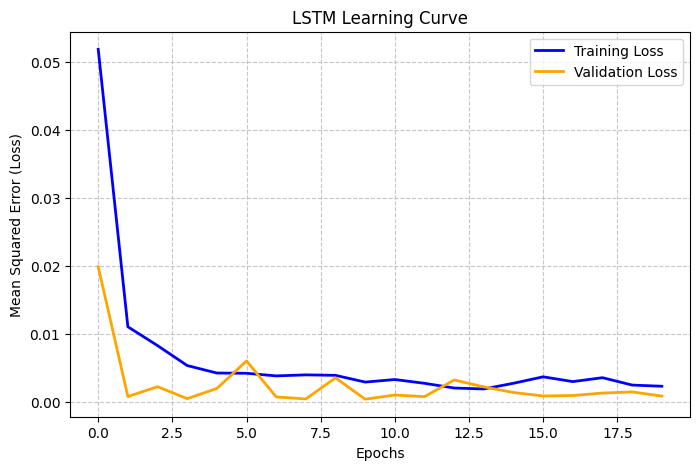

In [28]:
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


model.compile(optimizer='adam', loss='mean_squared_error', metrics=["mae"])

# with EarlyStopping
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
history = model.fit(
    x_train_scaled,
    y_train_scaled,
    validation_data=(x_val_scaled, y_val_scaled),
    batch_size=1,
    epochs=50,
    callbacks=callbacks
)

# # without EarlyStopping
# history = model.fit(
#     x_train_scaled,
#     y_train_scaled,
#     validation_data=(x_val_scaled, y_val_scaled),
#     batch_size=16,
#     epochs=50
# )

# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('LSTM Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Forecasting

In [29]:
import numpy as np

def recursive_forecast(model, df, scaler_x, scaler_y, forecast_days):

    # Get the initial input features (Open, High, Low, Volume) from the last known actual day
    current_features = df[['Open', 'High', 'Low', 'Volume']].iloc[-1].values.reshape(1, -1)

    # Get the last actual Open, High, Low, Volume to calculate deltas
    last_actual_open = df['Open'].iloc[-1]
    last_actual_high = df['High'].iloc[-1]
    last_actual_low = df['Low'].iloc[-1]
    last_actual_volume = df['Volume'].iloc[-1]

    # Calculate deltas from the last actual day
    high_delta = last_actual_high - last_actual_open
    low_delta = last_actual_open - last_actual_low # This should be a positive value

    predictions = []

    for _ in range(forecast_days):
        features_scaled = scaler_x.transform(current_features)
        X_pred = features_scaled.reshape(1, 4, 1).astype("float32")

        # Predict
        pred_scaled = model.predict(X_pred, verbose=0)

        # Inverse transform the prediction to get the actual price
        pred_close = scaler_y.inverse_transform(pred_scaled)[0, 0]
        predictions.append(pred_close)


        # Create sudo features for the next iteration
        current_features = np.array([[
            pred_close,                    # Open
            pred_close + high_delta,       # High
            pred_close - low_delta,        # Low
            last_actual_volume             # Volume
        ]])

    return np.array(predictions)


In [30]:
pred_1d = recursive_forecast(model, df, scaler_x, scaler_y, forecast_days=1)
pred_3d = recursive_forecast(model, df, scaler_x, scaler_y, forecast_days=3)
pred_5d = recursive_forecast(model, df, scaler_x, scaler_y, forecast_days=5)

print("1-day forecast:", pred_1d)
print("3-day forecast:", pred_3d)
print("5-day forecast:", pred_5d)

1-day forecast: [77.01997]
3-day forecast: [77.01997 76.13962 75.15213]
5-day forecast: [77.01997 76.13962 75.15213 74.05233 72.83748]


In [31]:
from sklearn.metrics import mean_absolute_error

def evaluate_horizon(model, df, scaler_x, scaler_y, start_idx, horizon):
    """
    start_idx: The index of the date to start the forecast.
    horizon: The number of trading days to predict.
    """

    history_df = df.iloc[:start_idx + 1].copy()
    predicted = recursive_forecast(
        model=model,
        df=history_df,
        scaler_x=scaler_x,
        scaler_y=scaler_y,
        forecast_days=horizon
    )
    actual = df["Close"].iloc[start_idx + 1 : start_idx + 1 + horizon].to_numpy()

    # Handle edge case where remaining data at the end of the dataset is shorter than the forecast horizon
    usable_len = min(len(predicted), len(actual))
    predicted = predicted[:usable_len]
    actual = actual[:usable_len]

    mae = mean_absolute_error(actual, predicted)

    return actual, predicted, mae

In [32]:
start_idx = len(df) - 6
for horizon in [1, 3, 5]:
    actual, predicted, mae = evaluate_horizon(
        model=model,
        df=df,
        scaler_x=scaler_x,
        scaler_y=scaler_y,
        start_idx=start_idx,
        horizon=horizon
    )
    print(f"\nHorizon: {horizon} day")
    print("Actual:   ", actual)
    print("Predicted:", predicted)
    print(f"MAE: {mae:.2f}")


Horizon: 1 day
Actual:    [76.01000214]
Predicted: [76.09548]
MAE: 0.09

Horizon: 3 day
Actual:    [76.01000214 77.40000153 80.31999969]
Predicted: [76.09548 75.82068 75.51242]
MAE: 2.16

Horizon: 5 day
Actual:    [76.01000214 77.40000153 80.31999969 77.90000153 76.46659851]
Predicted: [76.09548  75.82068  75.51242  75.167404 74.782196]
MAE: 2.18


In [33]:
def naive_forecast(last_close, horizon):
    return np.full(horizon, last_close)

for horizon in [1, 3, 5]:
    actual, predicted, lstm_mae = evaluate_horizon(model, df, scaler_x, scaler_y, start_idx, horizon)
    last_close = df["Close"].iloc[start_idx]
    naive_pred = naive_forecast(last_close, len(actual))
    naive_mae = mean_absolute_error(actual, naive_pred)

    print(f"\n--- {horizon}-day forecast ---")
    print(f"LSTM MAE:  {lstm_mae:.2f}")
    print(f"Naive MAE: {naive_mae:.2f}")


--- 1-day forecast ---
LSTM MAE:  0.09
Naive MAE: 0.02

--- 3-day forecast ---
LSTM MAE:  2.16
Naive MAE: 1.89

--- 5-day forecast ---
LSTM MAE:  2.18
Naive MAE: 1.60


# Plot 5-day prediction

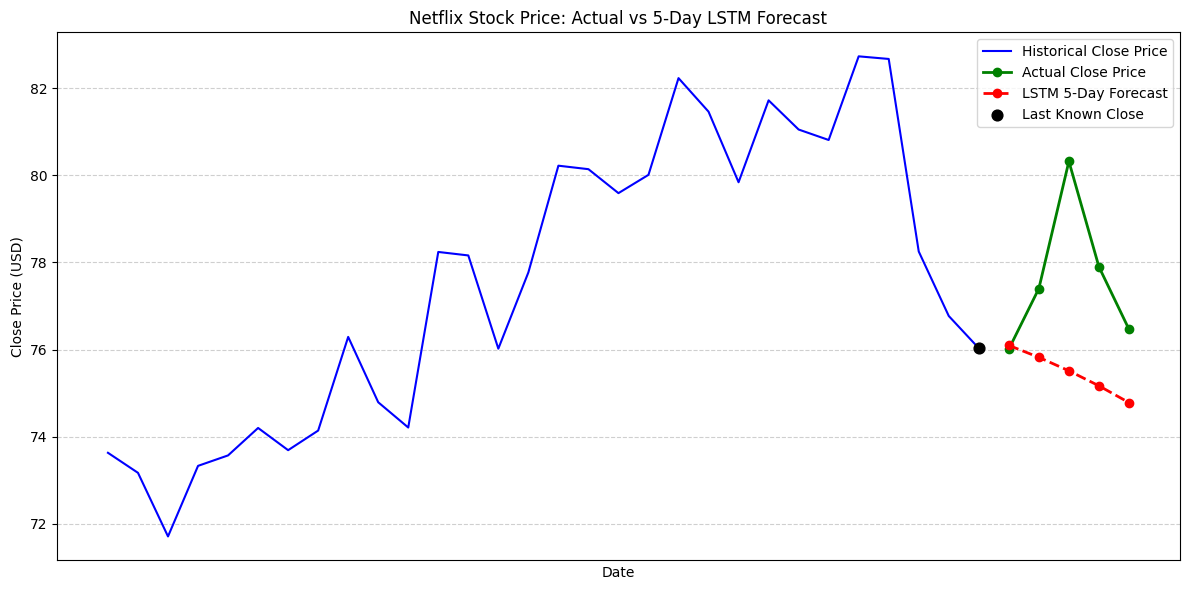

5-Day Forecast MAE: $2.18


In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# days to forecast
horizon = 5

start_idx = len(df) - horizon - 1
actual, predicted, mae = evaluate_horizon(
                            model=model, df=df,
                            scaler_x=scaler_x, scaler_y=scaler_y,
                            start_idx=start_idx, horizon=horizon
)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

forecast_dates = df.index[start_idx + 1 : start_idx + 1 + len(actual)]

last_known_date = df.index[start_idx]
last_known_close = df["Close"].iloc[start_idx]


plt.figure(figsize=(12, 6))

# Display historical data for the 30 days prior to the forecast start date
history_start = max(0, start_idx - 29)

plt.plot(df.index[history_start:start_idx + 1],
          df["Close"].iloc[history_start:start_idx + 1],
          label="Historical Close Price", color="blue"
)

plt.plot(forecast_dates, actual,
        label="Actual Close Price",
        color="green", marker="o", linewidth=2
)

plt.plot(forecast_dates, predicted,
          label=f"LSTM {horizon}-Day Forecast",
          color="red", linestyle="--", marker="o", linewidth=2
)

# จุดราคาจริงล่าสุดที่โมเดลใช้เป็นข้อมูลตั้งต้น
plt.scatter(last_known_date, last_known_close,
            color="black", s=60, zorder=5,
            label="Last Known Close"
)

plt.title(f"Netflix Stock Price: Actual vs {horizon}-Day LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"{horizon}-Day Forecast MAE: ${mae:.2f}")